<a href="https://colab.research.google.com/github/anjitha2002/SMS-Spam-Detection-Using-Machine-Learning/blob/main/SMS_Spam_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **SMS Spam Detection using Machine Learning**

This project identifies whether an incoming SMS message is Spam or Ham (Legitimate) using standard Natural Language Processing (NLP) techniques and Machine Learning (ML) algorithms.

**📌 Project Overview**

In this project, raw text messages are cleaned, preprocessed, and transformed using TF-IDF Feature Extraction. Multiple Machine Learning models are built, trained, and evaluated to compare performance metrics like accuracy, precision, recall, and F1-score.

**🛠️ Tech Stack & Libraries**

 * Language: Python
 * Data Handling & Analysis: pandas, numpy
 * Data Visualization: matplotlib, seaborn
 * Natural Language Processing (NLP): nltk, string, re
 * Machine Learning (scikit-learn):
   * Feature Extraction & Preprocessing: TfidfVectorizer, LabelEncoder, train_test_split
   * Classifiers:
     * Logistic Regression
     * Linear Support Vector Machine (Linear SVM)
     * K-Nearest Neighbors (KNN)
     * Random Forest Classifier
   * Evaluation Metrics: Accuracy, Precision, Recall, F1-Score, Confusion Matrix, Classification Report

**⚙️ Data Preprocessing & Pipeline**

 * Data Cleaning: Checked for missing values and removed unnecessary columns from the dataset.
 * Label Encoding: Encoded target categories (ham/spam) into numeric labels (0/1).
 * Text Normalization & Cleaning:
   * Converted text to lowercase.
   * Removed punctuation using Python's string.punctuation.
   * Filtered out English stopwords using nltk.corpus.stopwords.
 * Feature Extraction: Transformed cleaned text into a sparse matrix representation using TfidfVectorizer.
 * Data Splitting: Split the processed dataset into training and testing sets using train_test_split.

**📊 Model Comparison & Results**

The following classifiers were trained and evaluated on the test set:
 * Logistic Regression
 * Linear SVM
 * K-Nearest Neighbors (KNN)
 * Random Forest Classifier
Performance metrics (Accuracy, Precision, Recall, and F1-Score) for each model were plotted and compared visually to identify the best-performing algorithm.

**🔍 Feature Analysis (Top Spam Words)**

Extracted and visualized the Top 15 highest-scoring words in spam messages based on cumulative TF-IDF weights (e.g., call, free, claim, mobile, txt).

# Importing Libraries and Datasets

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

import nltk
from nltk.corpus import stopwords
import string

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,classification_report



In [57]:
spam=pd.read_csv("/content/spam.csv",encoding="latin-1")

In [58]:
spam

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


# Data Preprocessing

In [59]:
spam=spam[['v1','v2']]

In [60]:
spam

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [61]:
spam.columns=['label','message']

In [62]:
spam

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [63]:
print(spam.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None


In [64]:
print(spam.isnull().sum())

label      0
message    0
dtype: int64


In [65]:
le=LabelEncoder()

In [66]:
spam['label']=le.fit_transform(spam['label'])

/tmp/ipykernel_2066/3407235650.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spam['label']=le.fit_transform(spam['label'])


In [67]:
spam

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [68]:
spam.isnull().sum()

,0
label,0
message,0


In [69]:
spam['label'].value_counts()

,count
label,
0,4825
1,747


# Exploratory Data Analysis

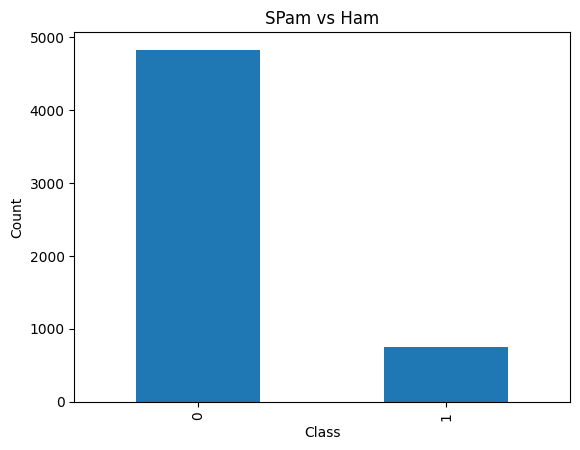

In [70]:
spam['label'].value_counts().plot(kind='bar')
plt.title("SPam vs Ham")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [71]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [72]:
# stop_words=set(stopwords.words('english'))
def clean_text(text):
  text=text.lower()
  punctuations=str.maketrans('', '', string.punctuation)
  text=text.translate(punctuations)

  return text

#   words=text.split()
#   text=[i for i in words if i not in stop_words]
#   return " ".join(text)

spam['message']=spam["message"].apply(clean_text)




/tmp/ipykernel_2066/4038147241.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  spam['message']=spam["message"].apply(clean_text)


In [73]:
spam

,label,message
0,0,go until jurong point crazy available only in ...
1,0,ok lar joking wif u oni
2,1,free entry in 2 a wkly comp to win fa cup fina...
3,0,u dun say so early hor u c already then say
4,0,nah i dont think he goes to usf he lives aroun...
...,...,...
5567,1,this is the 2nd time we have tried 2 contact u...
5568,0,will ì b going to esplanade fr home
5569,0,pity was in mood for that soany other suggest...
5570,0,the guy did some bitching but i acted like id ...


# Feature Extraction(TF-IDF)

In [74]:
x=spam['message']
y=spam['label']

In [75]:
tfidf=TfidfVectorizer()

In [76]:
x=tfidf.fit_transform(x)

In [77]:
x


<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 72459 stored elements and shape (5572, 9489)>

In [78]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [79]:
y_train

,label
1978,0
3989,1
3935,0
4078,0
4086,1
...,...
3772,0
5191,0
5226,0
5390,0


# Model Training and Evaluation

In [80]:
log=LogisticRegression(class_weight='balanced',random_state=42)

In [81]:
log.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', random_state=42)

In [82]:
log_pred=log.predict(x_test)

In [83]:
print("Acuuracy",accuracy_score(y_test,log_pred))
print("Precission",precision_score(y_test,log_pred))
print("Recall",recall_score(y_test,log_pred))
print("F1 Score",f1_score(y_test,log_pred))
print(classification_report(y_test,log_pred))

Acuuracy 0.9704035874439462
Precission 0.8979591836734694
Recall 0.88
F1 Score 0.8888888888888888
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       965
           1       0.90      0.88      0.89       150

    accuracy                           0.97      1115
   macro avg       0.94      0.93      0.94      1115
weighted avg       0.97      0.97      0.97      1115



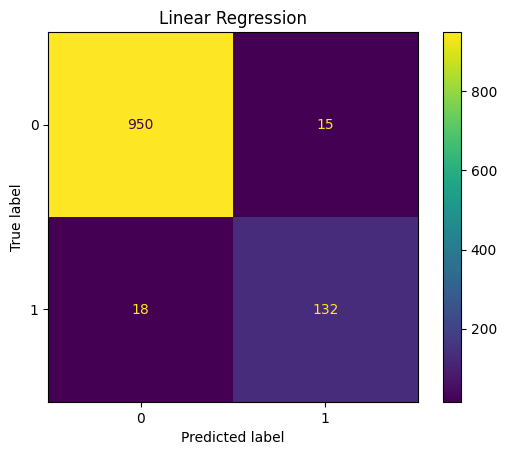

In [84]:
cm=confusion_matrix(y_test,log_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Linear Regression")
plt.show()

In [85]:
svm=LinearSVC(class_weight='balanced',random_state=42)

In [86]:
svm.fit(x_train,y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [87]:
svm_pred=svm.predict(x_test)

In [88]:
print("Acuuracy",accuracy_score(y_test,svm_pred))
print("Precission",precision_score(y_test,svm_pred))
print("Recall",recall_score(y_test,svm_pred))
print("F1 Score",f1_score(y_test,svm_pred))
print(classification_report(y_test,svm_pred))

Acuuracy 0.979372197309417
Precission 0.9703703703703703
Recall 0.8733333333333333
F1 Score 0.9192982456140351
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.97      0.87      0.92       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



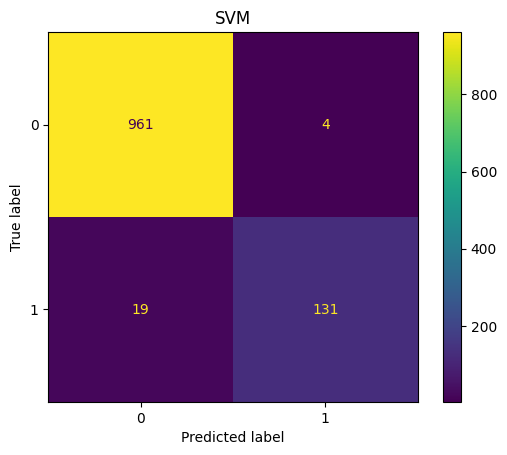

In [89]:
cm=confusion_matrix(y_test,svm_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("SVM")
plt.show()

In [90]:
knn=KNeighborsClassifier(n_neighbors=5)

In [91]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [92]:
knn_pred=knn.predict(x_test)

In [93]:
print("Acuuracy",accuracy_score(y_test,knn_pred))
print("Precission",precision_score(y_test,knn_pred))
print("Recall",recall_score(y_test,knn_pred))
print("F1 Score",f1_score(y_test,knn_pred))
print(classification_report(y_test,knn_pred))

Acuuracy 0.9103139013452914
Precission 1.0
Recall 0.3333333333333333
F1 Score 0.5
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       965
           1       1.00      0.33      0.50       150

    accuracy                           0.91      1115
   macro avg       0.95      0.67      0.73      1115
weighted avg       0.92      0.91      0.89      1115



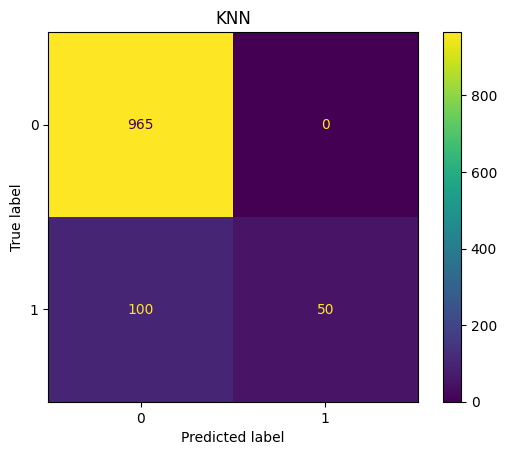

In [94]:
cm=confusion_matrix(y_test,knn_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("KNN")
plt.show()

In [95]:
rforest=RandomForestClassifier(class_weight='balanced',random_state=42)

In [96]:
rforest.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [97]:
rforest_pred=rforest.predict(x_test)

In [98]:
print("Acuuracy",accuracy_score(y_test,rforest_pred))
print("Precission",precision_score(y_test,rforest_pred))
print("Recall",recall_score(y_test,rforest_pred))
print("F1 Score",f1_score(y_test,rforest_pred))
print(classification_report(y_test,rforest_pred))

Acuuracy 0.9695067264573991
Precission 1.0
Recall 0.7733333333333333
F1 Score 0.8721804511278195
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.77      0.87       150

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



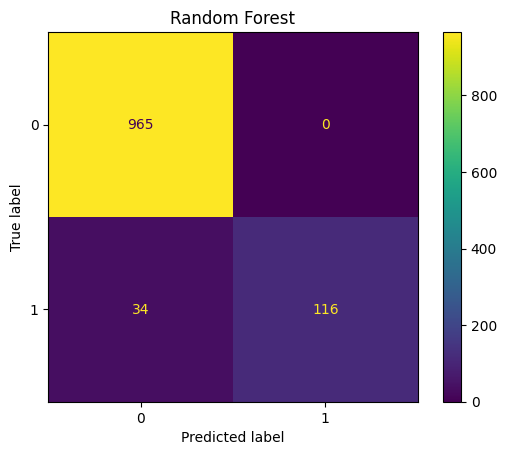

In [99]:
cm=confusion_matrix(y_test,rforest_pred)
ConfusionMatrixDisplay(cm).plot()
plt.title("Random Forest")
plt.show()

# Visualizing Model Result

In [100]:
result=pd.DataFrame({
    "Models":[
        "Logistic Regression",
        "Linear SVM",
        "KNN",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,log_pred),
        accuracy_score(y_test,svm_pred),
        accuracy_score(y_test,knn_pred),
        accuracy_score(y_test,rforest_pred)
    ],
    "Precision":[
        precision_score(y_test,log_pred),
        precision_score(y_test,svm_pred),
        precision_score(y_test,knn_pred),
        precision_score(y_test,rforest_pred),
    ],
    "Recall":[
        recall_score(y_test,log_pred),
        recall_score(y_test,svm_pred),
        recall_score(y_test,knn_pred),
        recall_score(y_test,rforest_pred),
    ],
    "F1 Score":[
        f1_score(y_test,log_pred),
        f1_score(y_test,svm_pred),
        f1_score(y_test,knn_pred),
        f1_score(y_test,rforest_pred),
    ]
})

print(result)

                Models  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.970404   0.897959  0.880000  0.888889
1           Linear SVM  0.979372   0.970370  0.873333  0.919298
2                  KNN  0.910314   1.000000  0.333333  0.500000
3        Random Forest  0.969507   1.000000  0.773333  0.872180


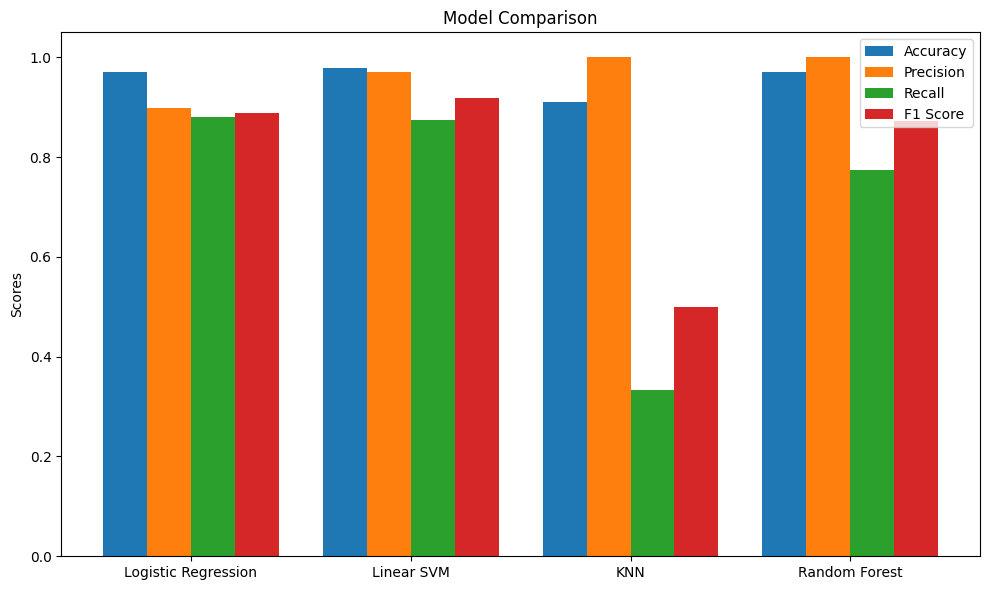

In [101]:
models = result["Models"]
accuracy = result["Accuracy"]
precision = result["Precision"]
recall = result["Recall"]
f1_score = result["F1 Score"]

x = np.arange(len(models))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width * 1.5, accuracy, width, label="Accuracy")
rects2 = ax.bar(x - width * 0.5, precision, width, label="Precision")
rects3 = ax.bar(x + width * 0.5, recall, width, label="Recall")
rects4 = ax.bar(x + width * 1.5, f1_score, width, label="F1 Score")

ax.set_ylabel("Scores")
ax.set_title("Model Comparison")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()

plt.tight_layout()
plt.show()


In [102]:
feature_name=tfidf.get_feature_names_out()
feature_name

array(['008704050406', '0089my', '0121', ..., 'ûïharry', 'ûò', 'ûówell'],
      dtype=object)

In [103]:
trained=x_train.toarray()
trained

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [104]:
spam_indices=np.where(y_train==1)[0]
spam_tfidf_sums=trained[spam_indices].sum(axis=0)

In [105]:
spam_indices

array([   1,    4,    6,   26,   29,   38,   51,   58,   71,   80,   90,
         96,  101,  103,  107,  108,  119,  121,  132,  146,  148,  157,
        172,  176,  178,  183,  187,  190,  194,  196,  200,  203,  208,
        212,  214,  217,  222,  248,  259,  264,  271,  292,  301,  303,
        306,  311,  327,  329,  334,  339,  342,  344,  358,  391,  414,
        421,  451,  467,  468,  478,  485,  492,  498,  502,  504,  512,
        519,  522,  531,  557,  564,  569,  571,  573,  587,  588,  610,
        611,  613,  626,  627,  630,  631,  642,  646,  651,  652,  659,
        661,  663,  667,  668,  672,  673,  675,  691,  694,  695,  703,
        712,  715,  723,  729,  734,  743,  748,  753,  761,  775,  776,
        780,  795,  804,  805,  806,  822,  844,  847,  851,  863,  866,
        871,  885,  886,  887,  893,  910,  924,  938,  995,  997,  999,
       1002, 1008, 1014, 1016, 1019, 1037, 1042, 1052, 1059, 1064, 1082,
       1084, 1086, 1091, 1095, 1099, 1104, 1119, 11

In [106]:
spam_tfidf_sums

array([0.52638474, 0.2514331 , 0.33116475, ..., 0.28870747, 0.        ,
       0.        ])

# Feature Extraction and Top 15 Words Analysis


In [107]:
top15_indices=spam_tfidf_sums.argsort()[-15:][::-1]
top15_indices

array([8417, 1950, 3587, 9430, 9413, 6088, 5903, 8615, 3536, 5532, 2226,
       8273, 3637, 8740, 7889])

In [108]:
top15_words=[feature_name[i]for i in top15_indices]
top15_words

['to',
 'call',
 'free',
 'your',
 'you',
 'or',
 'now',
 'txt',
 'for',
 'mobile',
 'claim',
 'the',
 'from',
 'ur',
 'stop']

In [109]:
top15_scores=[spam_tfidf_sums[i]for i in top15_indices]
top15_scores

[np.float64(40.562819784972426),
 np.float64(32.37154209746249),
 np.float64(24.68922713213188),
 np.float64(24.159780013662537),
 np.float64(19.685264880425564),
 np.float64(18.633605274109065),
 np.float64(18.13996954063956),
 np.float64(17.788888947107345),
 np.float64(17.769843540208274),
 np.float64(16.277599957980243),
 np.float64(16.096812602005212),
 np.float64(14.621956773414901),
 np.float64(14.513708443374576),
 np.float64(14.241610366760273),
 np.float64(14.03968940631089)]

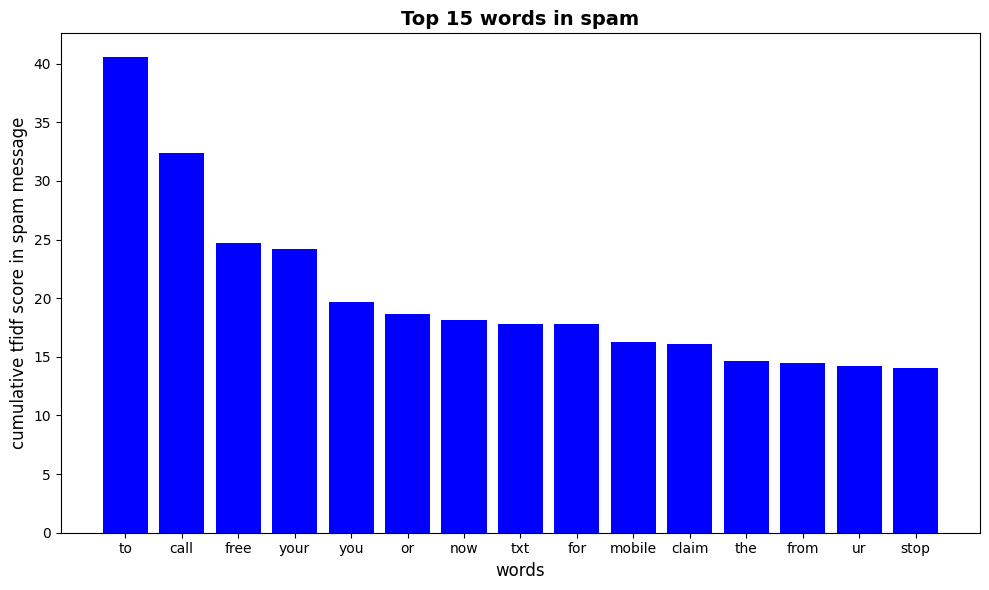

In [110]:
plt.figure(figsize=(10,6))
plt.bar(top15_words[::1],top15_scores[::1],color='blue')
plt.title("Top 15 words in spam" ,fontsize=14,fontweight='bold')
plt.ylabel("cumulative tfidf score in spam message",fontsize=12)
plt.xlabel("words",fontsize=12)
plt.tight_layout()
plt.show()
